# LLM-as-a-judge n2c2

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, cohen_kappa_score,f1_score

# n2c2 prompt 1 (prompt with detailed instructions)

## K5 - each criteria all notes strategy 

In [3]:
# upload the csv files 
df1 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt4o_run1.csv")
df2 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt4o_run2.csv")
df3 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt4o_run3.csv")

In [4]:
distribution = df1["assessed_category"].value_counts()
print(distribution)

assessed_category
assumption            26
logical_error         24
complete              24
extraction_error      23
partially_complete    11
Name: count, dtype: int64


In [5]:
distribution = df2["assessed_category"].value_counts()

print(distribution)

assessed_category
extraction_error      24
complete              24
logical_error         23
assumption            21
partially_complete    16
Name: count, dtype: int64


In [6]:
distribution = df3["assessed_category"].value_counts()
print(distribution)

assessed_category
extraction_error      26
assumption            25
logical_error         24
complete              24
partially_complete     9
Name: count, dtype: int64


In [7]:
def take_majority_vote(df1, df2, df3):
    if not (df1.index.equals(df2.index) and df1.index.equals(df3.index)):
        raise ValueError("df1, df2, and df3 do not have the same index numbers")

    final_df = df1.copy()

    # take majority vote
    votes = pd.concat(
        [
            df1["assessed_category"],
            df2["assessed_category"],
            df3["assessed_category"]
        ],
        axis=1
    )

    votes.columns = ["df1_vote", "df2_vote", "df3_vote"]

    final_df["assessed_category"] = votes.mode(axis=1)[0]

    return final_df

In [8]:
final_df_gpt_4_k5 = take_majority_vote(df1, df2, df3)

final_df_gpt_4_k5.to_csv("majority_vote_output.csv", index=False)

In [9]:
distribution = final_df_gpt_4_k5["assessed_category"].value_counts()

print(distribution)
print("Total:", distribution.sum())

assessed_category
assumption            25
complete              25
logical_error         24
extraction_error      23
partially_complete    11
Name: count, dtype: int64
Total: 108


In [10]:
final_df_gpt_4_k5.head(2)

,index,note,patient_id,criterion,rationale,medications,is_met,true_label,assessed_category,assessor_confidence,assessor_reason,assessor_evidence_ids,used_k,retrieved_count,latency_ms,error,llm_status,llm_error_type,llm_attempts
0,19,record date : 2107 - 10 - 24 toole county hosp...,115,DRUG-ABUSE,The clinical notes indicate that the patient i...,"['allopurinol 100 mg', 'amitriptyline 10 mg', ...",1,0,assumption,high,The model assumes that the use of Percocet for...,"[""115_3_1""]",5,5,3168,NaN,ok,NaN,1
1,23,record date : 2107 - 10 - 24 toole county hosp...,115,MAJOR-DIABETES,The patient has a history of diabetes mellitus...,"['diabeta', 'pravachol', 'atorvastatin', 'lopr...",0,1,partially_complete,medium,The model rationale correctly identifies that ...,"[""115_0_0"", ""115_1_0""]",5,5,3238,NaN,ok,NaN,1


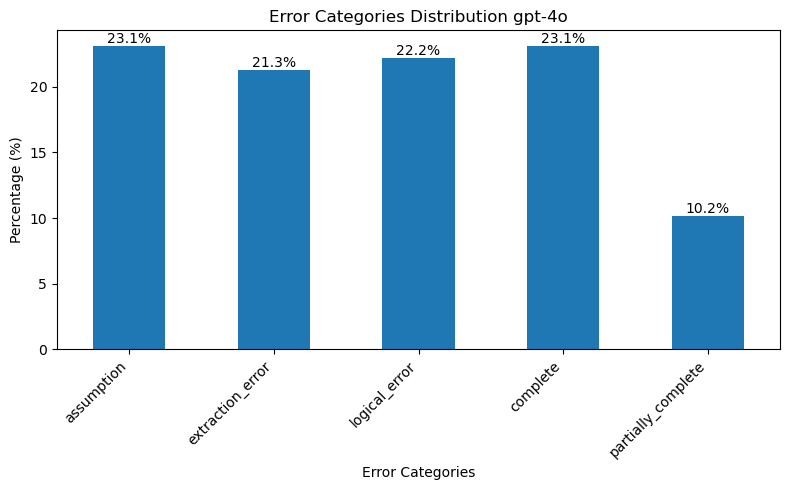

In [11]:
# Category distribution 
labels = [
    "assumption",
    "extraction_error",
    "logical_error",
    "complete",
    "partially_complete",
]

percentages = (
    final_df_gpt_4_k5["assessed_category"]
    .value_counts(normalize=True)
    .reindex(labels, fill_value=0) * 100
)

ax = percentages.plot(kind="bar", figsize=(8, 5))

plt.title("Error Categories Distribution gpt-4o")
plt.ylabel("Percentage (%)")
plt.xlabel("Error Categories")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(percentages.values):
    ax.text(
        i,
        v,
        f"{v:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("error_categories_distribution_gpt4o_percentages_prompt1.png", dpi=300, bbox_inches="tight")
plt.show()

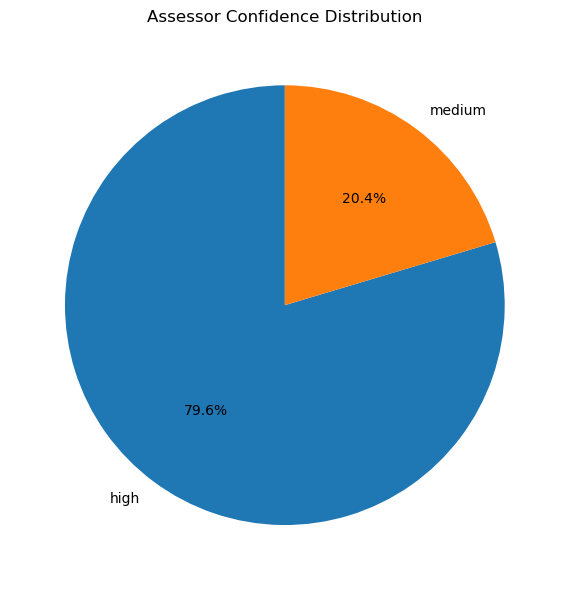

In [12]:
# Confidence Levels
confidence_counts = df1["assessor_confidence"].value_counts()
plt.figure(figsize=(6, 6))

plt.pie(
    confidence_counts.values,
    labels=confidence_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Assessor Confidence Distribution")

plt.tight_layout()

plt.savefig("assessor_confidence_pie_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
confidence_by_category = pd.crosstab(
    df1["assessed_category"],
    df1["assessor_confidence"]
)

print(confidence_by_category)

assessor_confidence  high  medium
assessed_category                
assumption             14      12
complete               24       0
extraction_error       23       0
logical_error          24       0
partially_complete      1      10


In [14]:
confidence_by_category_pct = pd.crosstab(
    df1["assessed_category"],
    df1["assessor_confidence"],
    normalize="index"
) * 100

print(confidence_by_category_pct.round(1))

assessor_confidence   high  medium
assessed_category                 
assumption            53.8    46.2
complete             100.0     0.0
extraction_error     100.0     0.0
logical_error        100.0     0.0
partially_complete     9.1    90.9


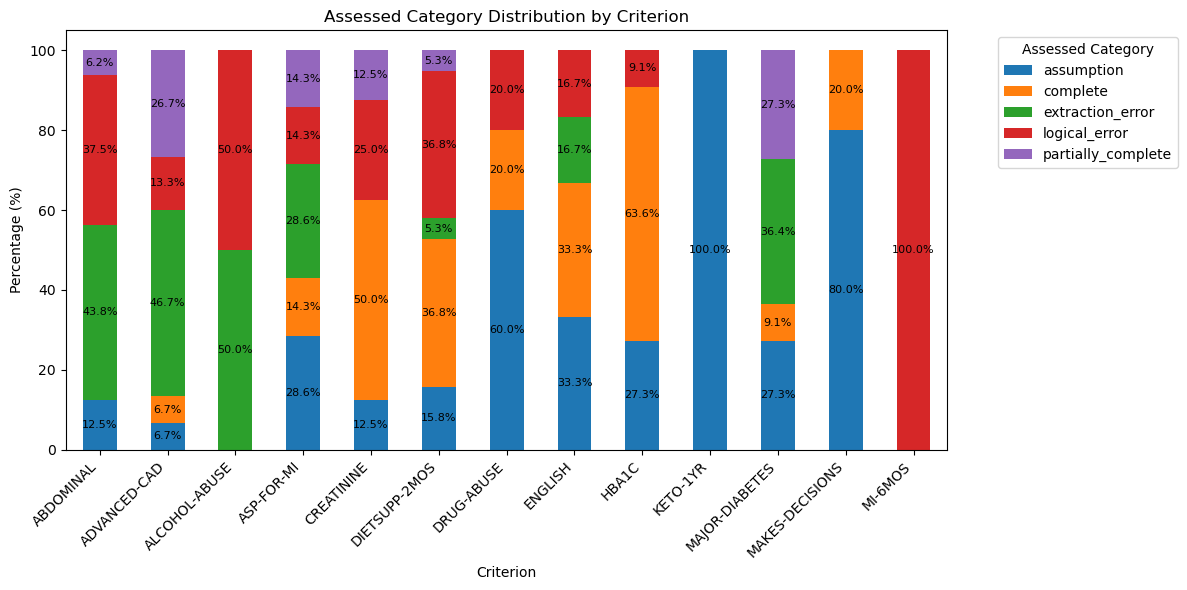

In [15]:
# error distribution in each criterion 
table_pct = pd.crosstab(
    final_df_gpt_4_k5["criterion"],
    final_df_gpt_4_k5["assessed_category"],
    normalize="index"
) * 100

ax = table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Assessed Category Distribution by Criterion")
plt.xlabel("Criterion")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Assessed Category", bbox_to_anchor=(1.05, 1), loc="upper left")

# write percentages on each stacked part
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" if v > 0 else "" for v in container.datavalues],
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("criterion_main_assessed_category_distribution_percentages.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
#confidence per criterion
confidence_per_criterion = pd.crosstab(
     final_df_gpt_4_k5["criterion"],
     final_df_gpt_4_k5["assessor_confidence"],
    normalize="index"
) * 100

print(confidence_per_criterion.round(2))

assessor_confidence    high  medium
criterion                          
ABDOMINAL             87.50   12.50
ADVANCED-CAD          73.33   26.67
ALCOHOL-ABUSE        100.00    0.00
ASP-FOR-MI            71.43   28.57
CREATININE            87.50   12.50
DIETSUPP-2MOS         89.47   10.53
DRUG-ABUSE            60.00   40.00
ENGLISH              100.00    0.00
HBA1C                100.00    0.00
KETO-1YR               0.00  100.00
MAJOR-DIABETES        45.45   54.55
MAKES-DECISIONS       60.00   40.00
MI-6MOS              100.00    0.00


## gpt-4o-mini

In [144]:
# upload the csv files 
df1_mini = pd.read_csv(r"D:\Downloads\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt_4o_mini_run3.csv")
df2_mini = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt_4omini_run2.csv")
df3_mini = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt_4omini_run1.csv")

In [18]:
distribution = df1_mini["assessed_category"].value_counts()
print(distribution)

assessed_category
partially_complete    35
assumption            25
extraction_error      22
logical_error         15
complete              11
Name: count, dtype: int64


In [19]:
distribution = df2_mini["assessed_category"].value_counts()
print(distribution)

assessed_category
partially_complete    36
assumption            25
extraction_error      21
logical_error         15
complete              11
Name: count, dtype: int64


In [20]:
distribution = df3_mini["assessed_category"].value_counts()
print(distribution)

assessed_category
partially_complete    36
assumption            25
extraction_error      23
logical_error         14
complete              10
Name: count, dtype: int64


In [145]:
final_df_gpt_4_mini_k5 = take_majority_vote(df1_mini, df1_mini, df1_mini)

final_df_gpt_4_mini_k5.to_csv("k5_gpt_40_mini_prompt1_majority_vote_output.csv", index=False)

In [146]:
distribution = final_df_gpt_4_mini_k5["assessed_category"].value_counts()

print(distribution)

assessed_category
partially_complete    35
assumption            25
extraction_error      22
logical_error         15
complete              11
Name: count, dtype: int64


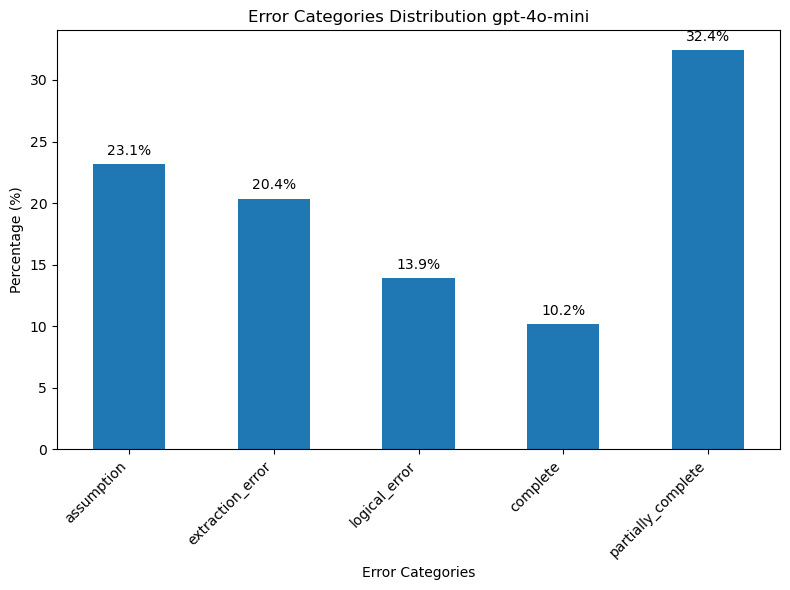

In [147]:
counts = final_df_gpt_4_mini_k5["assessed_category"].value_counts().reindex(labels, fill_value=0)

percentages = (
    final_df_gpt_4_mini_k5["assessed_category"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(labels, fill_value=0)
)

# Plot
ax = percentages.plot(kind="bar", figsize=(8, 6))

plt.title("Error Categories Distribution gpt-4o-mini")
plt.ylabel("Percentage (%)")
plt.xlabel("Error Categories")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(percentages.values):
    ax.text(
        i,
        v + 0.5,
        f"{v:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "error_categories_distribution_gpt4o_mini_percentages.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

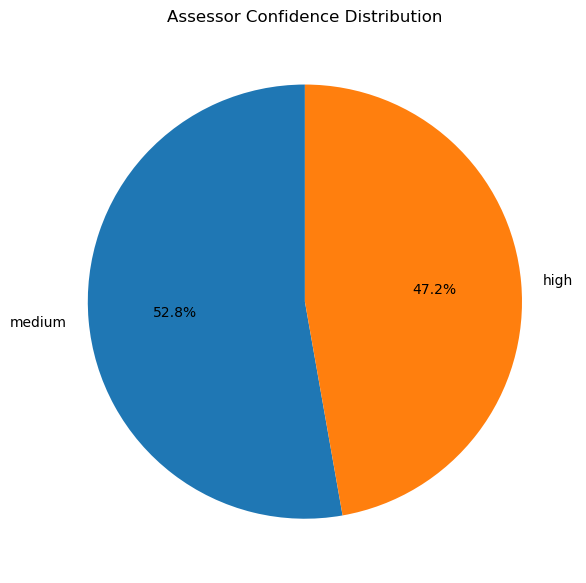

In [24]:
# Confidence Levels
confidence_counts = df1_mini["assessor_confidence"].value_counts()
plt.figure(figsize=(6, 6))

plt.pie(
    confidence_counts.values,
    labels=confidence_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Assessor Confidence Distribution")

plt.tight_layout()

plt.savefig("assessor_confidence_pie_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [148]:
confidence_by_category_pct = pd.crosstab(
    df1_mini["assessed_category"],
    df1_mini["assessor_confidence"],
    normalize="index"
) * 100

print(confidence_by_category_pct.round(1))

assessor_confidence   high  medium
assessed_category                 
assumption            24.0    76.0
complete             100.0     0.0
extraction_error      72.7    27.3
logical_error         93.3     6.7
partially_complete    11.4    88.6


## Excluding "partially_complete" from the analysis

In [26]:
# upload the csv files 
df1_4cat = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt_4o_mini_4cat_run1.csv")
df2_4cat = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt_4o_mini_4cat_ run3.csv")
df3_4cat = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_gpt_4o_mini_4_cat_run2.csv")

In [27]:
distribution = df1_4cat["assessed_category"].value_counts()
print(distribution)

assessed_category
extraction_error    53
assumption          33
complete            11
logical_error       11
Name: count, dtype: int64


In [28]:
distribution = df2_4cat["assessed_category"].value_counts()
print(distribution)

assessed_category
extraction_error    53
assumption          31
logical_error       13
complete            11
Name: count, dtype: int64


In [29]:
distribution = df3_4cat["assessed_category"].value_counts()
print(distribution)


assessed_category
extraction_error    55
assumption          32
complete            11
logical_error       10
Name: count, dtype: int64


In [30]:
confidence_by_category_pct = pd.crosstab(
    df1_4cat["assessed_category"],
    df1_4cat["assessor_confidence"],
    normalize="index"
) * 100
print(confidence_by_category_pct.round(1))

assessor_confidence   high  medium
assessed_category                 
assumption            24.2    75.8
complete             100.0     0.0
extraction_error      79.2    20.8
logical_error         81.8    18.2


In [31]:
final_df_gpt_4o_mini_4cat = take_majority_vote(df1_4cat, df2_4cat, df3_4cat)

In [32]:
distribution = final_df_gpt_4o_mini_4cat["assessed_category"].value_counts()

print(distribution)

assessed_category
extraction_error    54
assumption          31
logical_error       12
complete            11
Name: count, dtype: int64


## n2c2 prompt 2

In [33]:
df2_1 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_prompt2_run1.csv")
df2_2 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_prompt2_run2.csv")
df2_3 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k5_prompt2_run3.csv")

In [34]:
distribution = df2_1["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
assumption            24
logical_error         24
extraction_error      22
partially_complete    19
complete              19
Name: count, dtype: int64
Total: 108


In [35]:
distribution = df2_2["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
logical_error         26
complete              21
extraction_error      21
assumption            20
partially_complete    20
Name: count, dtype: int64
Total: 108


In [36]:
distribution = df2_3["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
logical_error         24
extraction_error      23
assumption            22
complete              21
partially_complete    18
Name: count, dtype: int64
Total: 108


In [37]:
final_df_gpt_4_k5_prompt2 = take_majority_vote(df1, df2, df3)

final_df_gpt_4_k5_prompt2.to_csv("majority_vote_output.csv", index=False)

In [38]:
distribution = final_df_gpt_4_k5_prompt2["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
assumption            25
complete              25
logical_error         24
extraction_error      23
partially_complete    11
Name: count, dtype: int64
Total: 108


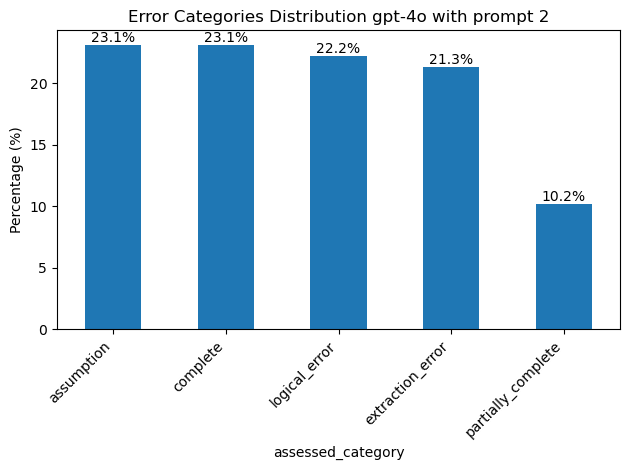

In [39]:
counts = final_df_gpt_4_k5_prompt2["assessed_category"].value_counts()
percentages = final_df_gpt_4_k5_prompt2["assessed_category"].value_counts(normalize=True) * 100
ax = percentages.plot(kind="bar")

plt.title("Error Categories Distribution gpt-4o with prompt 2")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
# Add percentage labels on bars
for i, v in enumerate(percentages.values):
    ax.text(
        i,
        v,
        f"{v:.1f}%",
        ha="center",
        va="bottom"
    )
    
plt.tight_layout()
plt.savefig("error_categories_distribution_gpt4o_mini_percentages_prompt2.png", dpi=300, bbox_inches="tight")
plt.show()

# Human Annotations


### Annotator 1 and annotator 2 compared only 50 rows and the remaining was done by annotator 1 only 

In [40]:
df_human = pd.read_excel(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\human_1_human_2_results_k5.xlsx")

In [41]:
df_human[["human1_clean", "human2_clean"]] = df_human[
    ["human1_annotation", "human2_annotaiton_complete"]
].astype(str).apply(lambda col: col.str.strip().str.lower())

In [42]:
df_human["agreement_label"] = df_human["human1_clean"].where(
    df_human["human1_clean"] == df_human["human2_clean"],
    "disagree"
)
df_human.to_excel("human_agreement_n2c2.xlsx", index=False)

In [43]:
df_human.head(2)

,index,patient_id,criterion,Unnamed: 3,criterion.1,rationale,medications,is_met,true_label,assessed_category,...,human1_confidence,human1_reaons,note,human2_annotation,human2_confidence,human_agreement,human2_note,human1_clean,human2_clean,agreement_label
0,2,115,MAJOR-DIABETES,NaN,MAJOR-DIABETES,The patient has a history of diabetes mellitus...,"['diabeta', 'pravachol', 'atorvastatin', 'lopr...",0,1,extraction_error,...,high,NaN,record date : 2107 - 10 - 24 toole county hosp...,complete,high,complete,NaN,complete,complete,complete
1,3,119,ADVANCED-CAD,NaN,ADVANCED-CAD,The patient is taking multiple medications for...,"['furosemide', 'asa (acetylsalicylic acid)', '...",1,0,logical_error,...,medium,did not understand criteria defination,record date : 2088 - 05 - 21 patient name : cu...,logical_error,high,logical_error,history of angina is intrepted same as current...,logical_error,logical_error,logical_error


In [46]:
kappa = cohen_kappa_score(
    df_human["human1_clean"],
    df_human["human2_clean"]
)

print("Cohen's Kappa:", round(kappa, 3))

Cohen's Kappa: 0.508


In [47]:
distribution = df_human["human2_clean"].value_counts(dropna=False)

print(distribution)
print("Total:", distribution.sum())

human2_clean
assumption                        20
complete                          13
extraction_error                  10
logical_error                      5
partially_complete                 3
partially_complete; assumption     3
Name: count, dtype: int64
Total: 54


In [48]:
distribution = df_human["human1_clean"].value_counts(dropna=False)

print(distribution)
print("Total:", distribution.sum())

human1_clean
assumption            20
complete              12
extraction_error      11
logical_error         10
partially_complete     1
Name: count, dtype: int64
Total: 54


In [49]:
distribution = df_human["human2_clean"].value_counts(dropna=False)

print(distribution)
print("Total:", distribution.sum())

human2_clean
assumption                        20
complete                          13
extraction_error                  10
logical_error                      5
partially_complete                 3
partially_complete; assumption     3
Name: count, dtype: int64
Total: 54


In [50]:
distribution = df_human["agreement_label"].value_counts(dropna=False)

print(distribution)
print("Total:", distribution.sum())

agreement_label
disagree              20
assumption            16
complete               7
logical_error          5
extraction_error       5
partially_complete     1
Name: count, dtype: int64
Total: 54


In [52]:
print(classification_report(
    df_human["human1_clean"],
    df_human["human2_clean"],
    labels=labels,
    zero_division=0
))

                    precision    recall  f1-score   support

        assumption       0.80      0.80      0.80        20
  extraction_error       0.50      0.45      0.48        11
     logical_error       1.00      0.50      0.67        10
          complete       0.54      0.58      0.56        12
partially_complete       0.33      1.00      0.50         1

         micro avg       0.67      0.63      0.65        54
         macro avg       0.63      0.67      0.60        54
      weighted avg       0.71      0.63      0.65        54



In [ ]:
# combine all human annotattions 

In [53]:
annotator_one_df = pd.read_excel(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\n2c2_human_1_annotation.xlsx")

In [54]:
df_human_small = df_human[["patient_id", "criterion", "agreement_label"]]
annotator_one_small = annotator_one_df[
    ["patient_id", "criterion", "human_annotation_complete"]
]
combined_df = annotator_one_small.merge(
    df_human_small,
    on=["patient_id", "criterion"],
    how="left"
)


In [55]:
combined_df

,patient_id,criterion,human_annotation_complete,agreement_label
0,115,DRUG-ABUSE,assumption,NaN
1,115,MAJOR-DIABETES,partially_complete,complete
2,119,ADVANCED-CAD,assumption,logical_error
3,120,ADVANCED-CAD,assumption,assumption
4,131,ABDOMINAL,complete,extraction_error
...,...,...,...,...
103,394,DRUG-ABUSE,logical_error,logical_error
104,396,DRUG-ABUSE,logical_error,logical_error
105,399,ABDOMINAL,logical_error,NaN
106,399,ASP-FOR-MI,extraction_error,NaN


In [56]:
agreement_counts = combined_df["agreement_label"].value_counts(dropna=False)
print(agreement_counts)

agreement_label
NaN                   54
disagree              20
assumption            16
complete               7
logical_error          5
extraction_error       5
partially_complete     1
Name: count, dtype: int64


In [57]:
agreement_counts = combined_df["human_annotation_complete"].value_counts(dropna=False)
print(agreement_counts)

human_annotation_complete
extraction_error      23
logical_error         22
complete              19
assumption            15
partially_complete    12
extraction_error       9
assumption             5
complete               3
Name: count, dtype: int64


In [58]:
combined_df["human_annotation_complete"] = (
    combined_df["human_annotation_complete"]
    .astype(str)
    .str.strip()
)

In [59]:
agreement_counts = combined_df["human_annotation_complete"].value_counts(dropna=False)
print(agreement_counts)

human_annotation_complete
extraction_error      32
complete              22
logical_error         22
assumption            20
partially_complete    12
Name: count, dtype: int64


In [60]:
combined_df["final_human_agreement"] = combined_df["agreement_label"].fillna(
    combined_df["human_annotation_complete"]
)

In [61]:
# combine all rows from agreement df and human annotator 1 df 
agreement_counts = combined_df["final_human_agreement"].value_counts(dropna=False)
print(agreement_counts)

final_human_agreement
assumption            25
extraction_error      25
logical_error         20
disagree              20
complete              16
partially_complete     2
Name: count, dtype: int64


In [62]:
# drop disagreement to measure accuracy and F1 scores later 
combined_df = combined_df[combined_df["final_human_agreement"] != "disagree"]

In [63]:
print(combined_df.columns)

Index(['patient_id', 'criterion', 'human_annotation_complete',
       'agreement_label', 'final_human_agreement'],
      dtype='object')


In [64]:
len(combined_df)

88

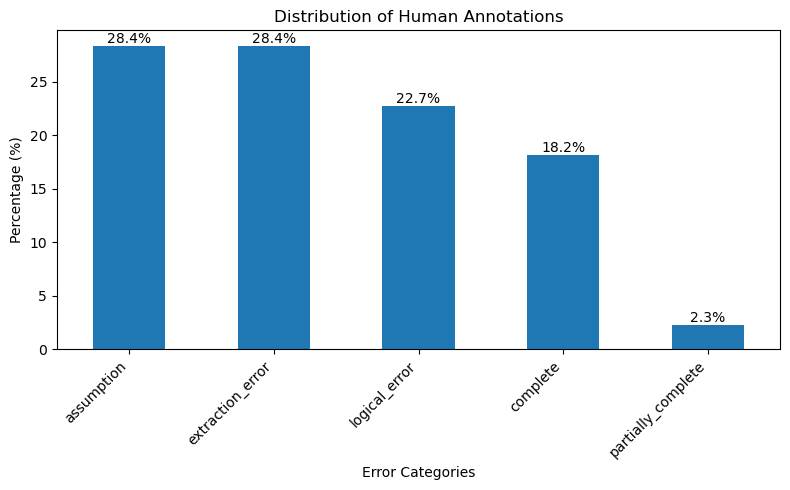

In [65]:
percentages = combined_df["final_human_agreement"].value_counts(normalize=True) * 100

# plot
ax = percentages.plot(kind="bar", figsize=(8, 5))

plt.title("Distribution of Human Annotations")
plt.ylabel("Percentage (%)")
plt.xlabel("Error Categories")
plt.xticks(rotation=45, ha="right")

# add percentage labels on bars
for i, v in enumerate(percentages.values):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("final_human_agreement_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


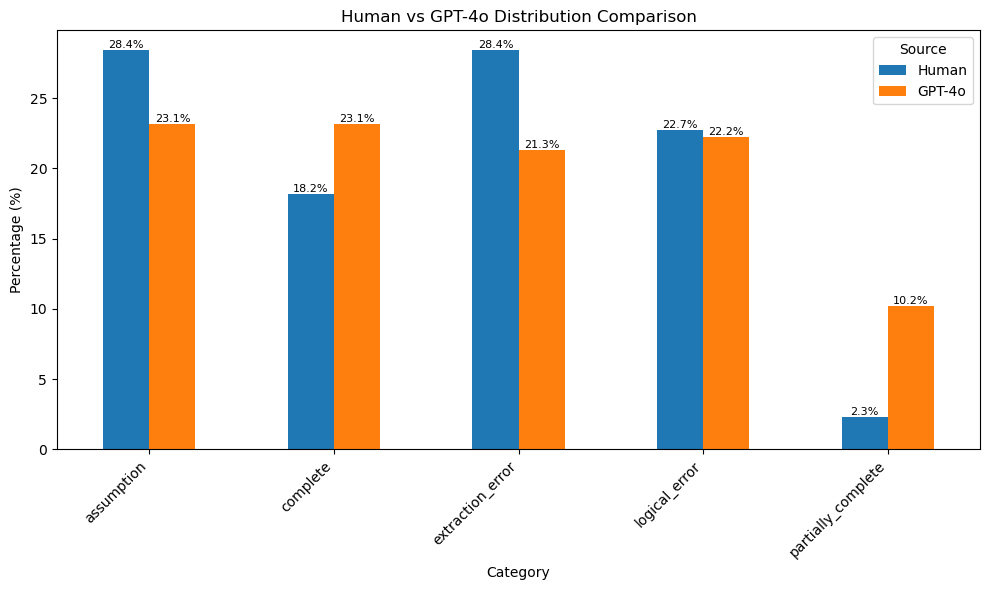

In [66]:
human_pct = combined_df["final_human_agreement"].value_counts(normalize=True) * 100
gpt_pct = final_df_gpt_4_k5["assessed_category"].value_counts(normalize=True) * 100

# align categories
all_labels = sorted(set(human_pct.index).union(set(gpt_pct.index)))

human_pct = human_pct.reindex(all_labels, fill_value=0)
gpt_pct = gpt_pct.reindex(all_labels, fill_value=0)

# combine into one df
compare_df = pd.DataFrame({
    "Human": human_pct,
    "GPT-4o": gpt_pct
})

# plot
ax = compare_df.plot(kind="bar", figsize=(10, 6))

plt.title("Human vs GPT-4o Distribution Comparison")
plt.ylabel("Percentage (%)")
plt.xlabel("Category")
plt.xticks(rotation=45, ha="right")

# add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.legend(title="Source")
plt.tight_layout()
plt.savefig("human_vs_gpt_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

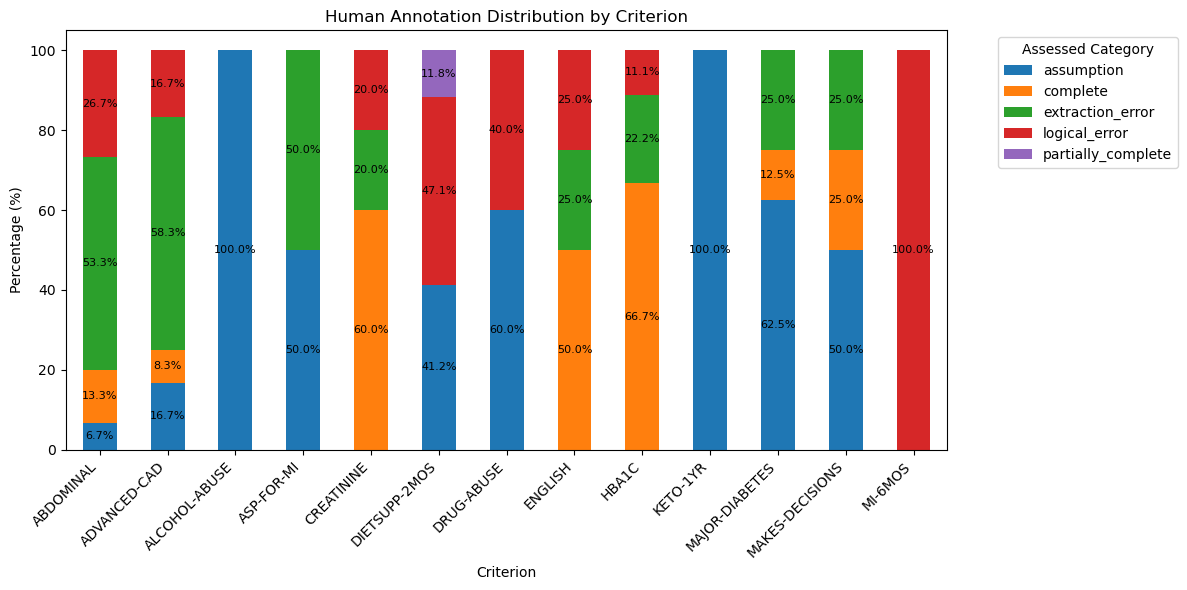

In [67]:
# error distribution in each criterion 
table_pct = pd.crosstab(
    combined_df["criterion"],
    combined_df["final_human_agreement"],
    normalize="index"
) * 100

ax = table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Human Annotation Distribution by Criterion")
plt.xlabel("Criterion")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Assessed Category", bbox_to_anchor=(1.05, 1), loc="upper left")

# write percentages on each stacked part
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" if v > 0 else "" for v in container.datavalues],
        label_type="center",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("criterion_human_annotation_distribution_percentages.png", dpi=300, bbox_inches="tight")
plt.show()

## Using K 10 chunks anf gpt-4o

In [68]:
df_k10_1 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k10_run1.csv")
df_k10_2 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k10_run2.csv")
df_k10_3 = pd.read_csv(r"D:\amal_2\MSc_Medical_Informatics\research report\results\results_n2c2\gpt-4o-mini_sentence-transformers_all-MiniLM-L6-v2_5_each_criteria_all_notes_test_chunk_criteria-all_results_k10_run3.csv")

In [69]:
distribution = df_k10_1["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
logical_error         29
extraction_error      22
assumption            20
complete              20
partially_complete     9
Name: count, dtype: int64
Total: 100


In [70]:
distribution = df_k10_2["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
extraction_error      28
logical_error         27
complete              23
assumption            21
partially_complete     9
Name: count, dtype: int64
Total: 108


In [71]:
distribution = df_k10_3["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
extraction_error      29
logical_error         27
complete              23
assumption            21
partially_complete     8
Name: count, dtype: int64
Total: 108


In [72]:
final_df_gpt_k10= take_majority_vote(df_k10_1, df_k10_2, df_k10_3)

In [73]:
distribution = final_df_gpt_k10["assessed_category"].value_counts()
print(distribution)
print("Total:", distribution.sum())

assessed_category
logical_error         28
extraction_error      27
complete              23
assumption            21
partially_complete     9
Name: count, dtype: int64
Total: 108


In [74]:
confidence_by_category_pct = pd.crosstab(
    final_df_gpt_k10["assessed_category"],
    final_df_gpt_k10["assessor_confidence"],
    normalize="index"
) * 100

print(confidence_by_category_pct.round(1))

assessor_confidence   high  medium
assessed_category                 
assumption            60.0    40.0
complete             100.0     0.0
extraction_error     100.0     0.0
logical_error         96.4     3.6
partially_complete    12.5    87.5


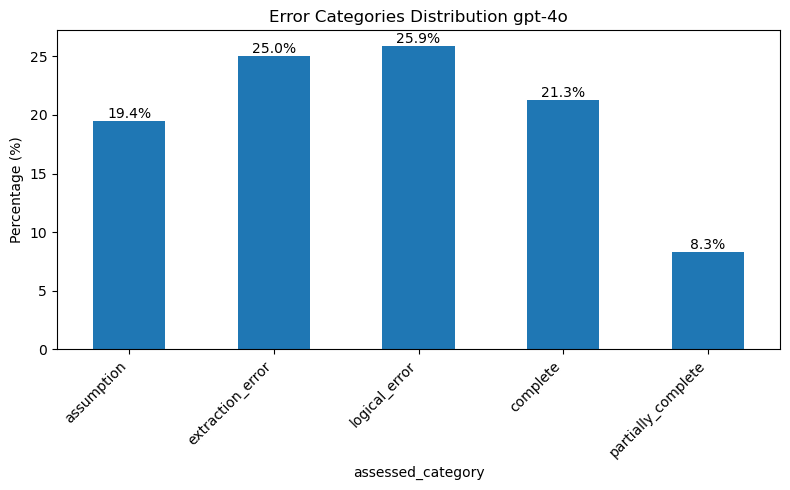

In [75]:
# Category distribution 
percentages = (
    final_df_gpt_k10["assessed_category"]
    .value_counts(normalize=True)
    .reindex(labels, fill_value=0) * 100
)

ax = percentages.plot(kind="bar", figsize=(8, 5))

plt.title("Error Categories Distribution gpt-4o")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(percentages.values):
    ax.text(
        i,
        v,
        f"{v:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("error_categories_distribution_gpt4o_k10.png", dpi=300, bbox_inches="tight")
plt.show()

# Measure Misclassication 

### gpt-4o using k5 and prompt 1

In [76]:
# K5 / gpt-4o / prompt 1
df_compare = pd.merge(
    combined_df,
    final_df_gpt_4_k5[["patient_id", "criterion", "assessed_category"]],
    on=["patient_id", "criterion"],
    how="left"
)

df_compare = df_compare.rename(columns={
    "assessed_category": "gpt_4_k5_prediction"
})

In [77]:
print(df_compare.head())


   patient_id       criterion human_annotation_complete   agreement_label  \
0         115      DRUG-ABUSE                assumption               NaN   
1         115  MAJOR-DIABETES        partially_complete          complete   
2         119    ADVANCED-CAD                assumption     logical_error   
3         120    ADVANCED-CAD                assumption        assumption   
4         131       ABDOMINAL                  complete  extraction_error   

  final_human_agreement gpt_4_k5_prediction  
0            assumption          assumption  
1              complete  partially_complete  
2         logical_error       logical_error  
3            assumption  partially_complete  
4      extraction_error       logical_error  


In [78]:
df_compare.shape

(88, 6)

In [81]:
report = classification_report(
    df_compare['final_human_agreement'],
    df_compare['gpt_4_k5_prediction'],
    zero_division=0,
    output_dict=True
)

In [82]:
# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Save for Excel
report_df.to_csv("classification_report_gpt_4_k5.csv", index=True)

In [83]:
display(report_df.round(3))

,precision,recall,f1-score,support
assumption,0.667,0.560,0.609,25.000
complete,0.526,0.625,0.571,16.000
extraction_error,0.889,0.640,0.744,25.000
logical_error,0.800,0.800,0.800,20.000
partially_complete,0.100,0.500,0.167,2.000
accuracy,0.648,0.648,0.648,0.648
macro avg,0.596,0.625,0.578,88.000
weighted avg,0.722,0.648,0.674,88.000


In [99]:
def get_f1_score (df, true_col, pred_col):
    y_true = df[true_col]
    y_pred = df[pred_col]

    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("Micro F1:", round(micro_f1, 3))
    print("Weighted F1:", round(weighted_f1, 3))

In [104]:
get_f1_score( df_compare,"final_human_agreement","gpt_4_k5_prediction")

Micro F1: 0.648
Weighted F1: 0.674


In [105]:
def plot_confusion_matrix(df, true_col, pred_col, labels, title="Confusion Matrix"):
    y_true = df[true_col]
    y_pred = df[pred_col]
    cm = confusion_matrix(y_true, y_pred, labels= labels)

    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels,
        
    )
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

In [106]:
labels = [
    "assumption",
    "extraction_error",
    "logical_error",
    "complete",
    "partially_complete",
]

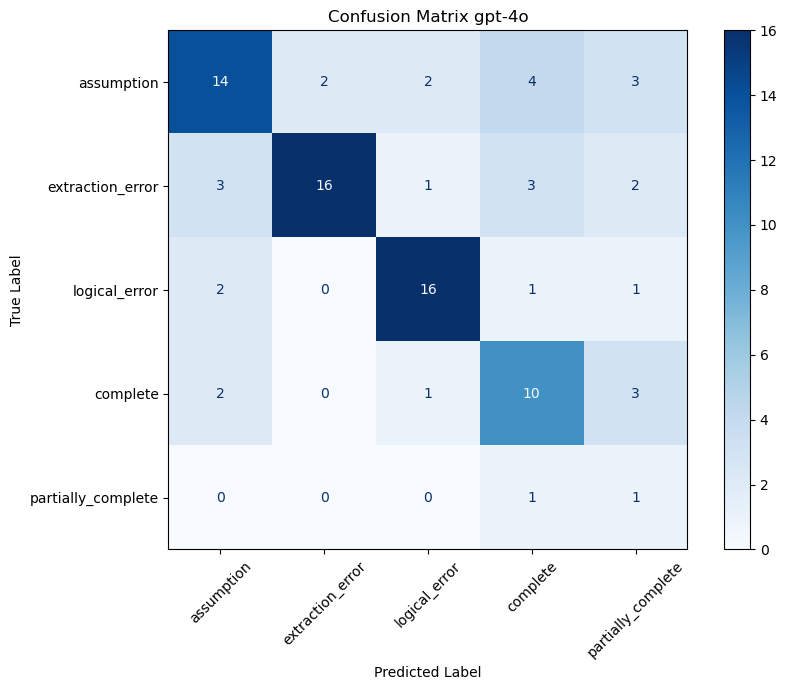

In [107]:
plot_confusion_matrix(
    df_compare,
    true_col="final_human_agreement",
    pred_col="gpt_4_k5_prediction",
    labels=labels,
    title="Confusion Matrix gpt-4o"
)

In [108]:
# testing for bootstrapping 
y_true = df_compare['final_human_agreement']
y_pred = df_compare['gpt_4_k5_prediction']

n_iterations = 1000
f1_scores = []

for _ in range(n_iterations):
    # sample with replacement
    indices = np.random.choice(len(y_true), size=len(y_true), replace=True)

    y_true_sample = y_true.iloc[indices]
    y_pred_sample = y_pred.iloc[indices]

    f1 = f1_score(y_true_sample, y_pred_sample, average="weighted", zero_division=0)
    f1_scores.append(f1)

# convert to array
f1_scores = np.array(f1_scores)

# f1 scores
mean_f1 = f1_scores.mean()
lower = np.percentile(f1_scores, 2.5)
upper = np.percentile(f1_scores, 97.5)

print(f"Weighted F1: {mean_f1:.3f}")
print(f"95% CI: [{lower:.3f}, {upper:.3f}]")

Weighted F1: 0.674
95% CI: [0.572, 0.770]


In [109]:
# per criterion 
def calculate_f1_per_criterion(
    df,
    true_col,
    pred_col,
    criterion):
    results = []

    for crit, group in df.groupby(criterion):
        y_true = group[true_col]
        y_pred = group[pred_col]

        f1 = f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        results.append({
            "criterion": crit,
            "f1_weighted": f1,
            "n_samples": len(group)
        })

    return pd.DataFrame(results).sort_values(
        "f1_weighted",
        ascending=False
    )

In [110]:
f1_per_criterion = calculate_f1_per_criterion(df_compare, "final_human_agreement", "gpt_4_k5_prediction", "criterion")

# Save to CSV
f1_per_criterion.to_csv("f1_per_criterion_gpt_4_k5.csv", index=False)

display(f1_per_criterion)

,criterion,f1_weighted,n_samples
9,KETO-1YR,1.000000,1
12,MI-6MOS,1.000000,1
6,DRUG-ABUSE,0.866667,5
0,ABDOMINAL,0.779259,15
7,ENGLISH,0.750000,4
1,ADVANCED-CAD,0.702020,12
5,DIETSUPP-2MOS,0.682353,17
10,MAJOR-DIABETES,0.668750,8
8,HBA1C,0.666667,9
11,MAKES-DECISIONS,0.650000,4


In [111]:
f1_per_criterion["f1_weighted"] = f1_per_criterion["f1_weighted"].round(3)

f1_per_criterion.to_excel("f1_per_criterion_gpt_4o.xlsx", index=False)

### prompt 2 

In [112]:
# prompt 2 
df_compare_2 = pd.merge(
    combined_df,
    final_df_gpt_4_k5_prompt2[["patient_id", "criterion", "assessed_category"]],
    on=["patient_id", "criterion"],
    how="left"
)

df_compare_2 = df_compare_2.rename(columns={
    "assessed_category": "prompt2_prediction"
})


In [92]:
df_compare_2.shape

(88, 6)

In [113]:
report = classification_report(
    df_compare_2['final_human_agreement'],
    df_compare_2['prompt2_prediction'],
    zero_division=0,
     output_dict=True
)

In [114]:
# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Save for Excel
report_df.to_csv("classification_report_gpt_4_k5.csv", index=True)

In [95]:
display(report_df.round(3))

,precision,recall,f1-score,support
assumption,0.667,0.560,0.609,25.000
complete,0.526,0.625,0.571,16.000
extraction_error,0.889,0.640,0.744,25.000
logical_error,0.800,0.800,0.800,20.000
partially_complete,0.100,0.500,0.167,2.000
accuracy,0.648,0.648,0.648,0.648
macro avg,0.596,0.625,0.578,88.000
weighted avg,0.722,0.648,0.674,88.000


In [115]:
get_f1_score( df_compare_2,"final_human_agreement","prompt2_prediction")

Micro F1: 0.648
Weighted F1: 0.674


In [116]:
# bootstrapping 
y_true = df_compare_2['final_human_agreement']
y_pred = df_compare_2['prompt2_prediction']

n_iterations = 1000
f1_scores = []

for _ in range(n_iterations):
    # sample with replacement
    indices = np.random.choice(len(y_true), size=len(y_true), replace=True)

    y_true_sample = y_true.iloc[indices]
    y_pred_sample = y_pred.iloc[indices]

    f1 = f1_score(y_true_sample, y_pred_sample, average="weighted", zero_division=0)
    f1_scores.append(f1)

# convert to array
f1_scores = np.array(f1_scores)

# statistics
mean_f1 = f1_scores.mean()
lower = np.percentile(f1_scores, 2.5)
upper = np.percentile(f1_scores, 97.5)

print(f"Weighted F1: {mean_f1:.3f}")
print(f"95% CI: [{lower:.3f}, {upper:.3f}]")

Weighted F1: 0.675
95% CI: [0.578, 0.769]


### gpt-4o-mini (all categories)

In [149]:
df_compare_mini = pd.merge(
    combined_df,
    final_df_gpt_4_mini_k5[["patient_id", "criterion", "assessed_category"]],
    on=["patient_id", "criterion"],
    how="left"
)

df_compare_mini = df_compare_mini.rename(columns={
    "assessed_category": "gpt_4o_mini_k5_prediction"
})

In [150]:
report = classification_report(
    df_compare_mini['final_human_agreement'],
    df_compare_mini['gpt_4o_mini_k5_prediction'],
    zero_division=0,
    output_dict=True
)

In [151]:
# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Save for Excel
report_df.to_csv("classification_report_gpt_4o_mini_k5.csv", index=True)

In [152]:
display(report_df.round(3))

,precision,recall,f1-score,support
assumption,0.455,0.400,0.426,25.000
complete,0.250,0.125,0.167,16.000
extraction_error,0.500,0.400,0.444,25.000
logical_error,0.455,0.250,0.323,20.000
partially_complete,0.037,0.500,0.069,2.000
accuracy,0.318,0.318,0.318,0.318
macro avg,0.339,0.335,0.286,88.000
weighted avg,0.421,0.318,0.352,88.000


In [153]:
y_true = df_compare_mini['final_human_agreement']
y_pred = df_compare_mini['gpt_4o_mini_k5_prediction']

n_iterations = 1000
f1_scores = []

for _ in range(n_iterations):
    # sample with replacement
    indices = np.random.choice(len(y_true), size=len(y_true), replace=True)

    y_true_sample = y_true.iloc[indices]
    y_pred_sample = y_pred.iloc[indices]

    f1 = f1_score(y_true_sample, y_pred_sample, average="weighted", zero_division=0)
    f1_scores.append(f1)

# convert to array
f1_scores = np.array(f1_scores)

# f1
mean_f1 = f1_scores.mean()
lower = np.percentile(f1_scores, 2.5)
upper = np.percentile(f1_scores, 97.5)

print(f"Weighted F1: {mean_f1:.3f}")
print(f"95% CI: [{lower:.3f}, {upper:.3f}]")

Weighted F1: 0.353
95% CI: [0.253, 0.460]


In [122]:
get_f1_score( df_compare_mini,"final_human_agreement","gpt_4o_mini_k5_prediction")

Micro F1: 0.648
Weighted F1: 0.674


In [154]:
f1_per_criterion_mini = calculate_f1_per_criterion(df_compare_mini, "final_human_agreement", "gpt_4o_mini_k5_prediction", "criterion")

print(f1_per_criterion_mini)

          criterion  f1_weighted  n_samples
9          KETO-1YR     1.000000          1
0         ABDOMINAL     0.572549         15
10   MAJOR-DIABETES     0.523810          8
5     DIETSUPP-2MOS     0.433155         17
3        ASP-FOR-MI     0.416667          6
11  MAKES-DECISIONS     0.333333          4
4        CREATININE     0.300000          5
6        DRUG-ABUSE     0.300000          5
8             HBA1C     0.118519          9
1      ADVANCED-CAD     0.111111         12
2     ALCOHOL-ABUSE     0.000000          1
7           ENGLISH     0.000000          4
12          MI-6MOS     0.000000          1


In [124]:
f1_per_criterion_mini["f1_weighted"] = f1_per_criterion_mini["f1_weighted"].round(3)

f1_per_criterion_mini.to_excel("f1_per_criterion_mini.xlsx", index=False)

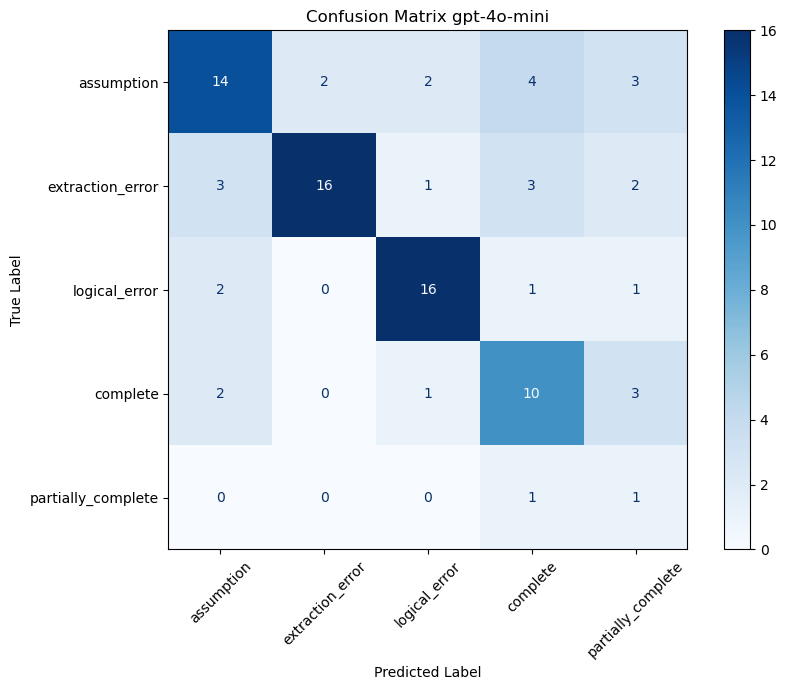

In [125]:
plot_confusion_matrix(
    df_compare_mini,
    true_col="final_human_agreement",
    pred_col="gpt_4o_mini_k5_prediction",
    labels=labels,
    title="Confusion Matrix gpt-4o-mini"
)

### gpt-4o-mini excluding "partially_complete"

In [126]:
df_compare_4cat = pd.merge(
    combined_df,
   final_df_gpt_4o_mini_4cat[["patient_id", "criterion", "assessed_category"]],
    on=["patient_id", "criterion"],
    how="left"
)

df_compare_4cat = df_compare_4cat.rename(columns={
    "assessed_category": "gpt_4cat_prediction"
})

In [127]:
df_compare_4cat.shape

(88, 6)

In [128]:
df_compare_4cat_filtered = df_compare_4cat[
    df_compare_4cat["final_human_agreement"]
    .astype(str)
    .str.strip()

    .str.lower() != "partially_complete"
].copy()

In [129]:
df_compare_4cat_filtered.shape

(86, 6)

In [130]:
df_compare_4cat_filtered.head()

,patient_id,criterion,human_annotation_complete,agreement_label,final_human_agreement,gpt_4cat_prediction
0,115,DRUG-ABUSE,assumption,NaN,assumption,assumption
1,115,MAJOR-DIABETES,partially_complete,complete,complete,assumption
2,119,ADVANCED-CAD,assumption,logical_error,logical_error,extraction_error
3,120,ADVANCED-CAD,assumption,assumption,assumption,extraction_error
4,131,ABDOMINAL,complete,extraction_error,extraction_error,complete


In [131]:
print(classification_report(
  df_compare_4cat_filtered['final_human_agreement'],
  df_compare_4cat_filtered['gpt_4cat_prediction'],
    zero_division=0
))

                  precision    recall  f1-score   support

      assumption       0.52      0.52      0.52        25
        complete       0.17      0.06      0.09        16
extraction_error       0.45      0.84      0.58        25
   logical_error       0.50      0.20      0.29        20

        accuracy                           0.45        86
       macro avg       0.41      0.41      0.37        86
    weighted avg       0.43      0.45      0.40        86



In [132]:
get_f1_score( df_compare_4cat_filtered,"final_human_agreement","gpt_4cat_prediction")

Micro F1: 0.453
Weighted F1: 0.404


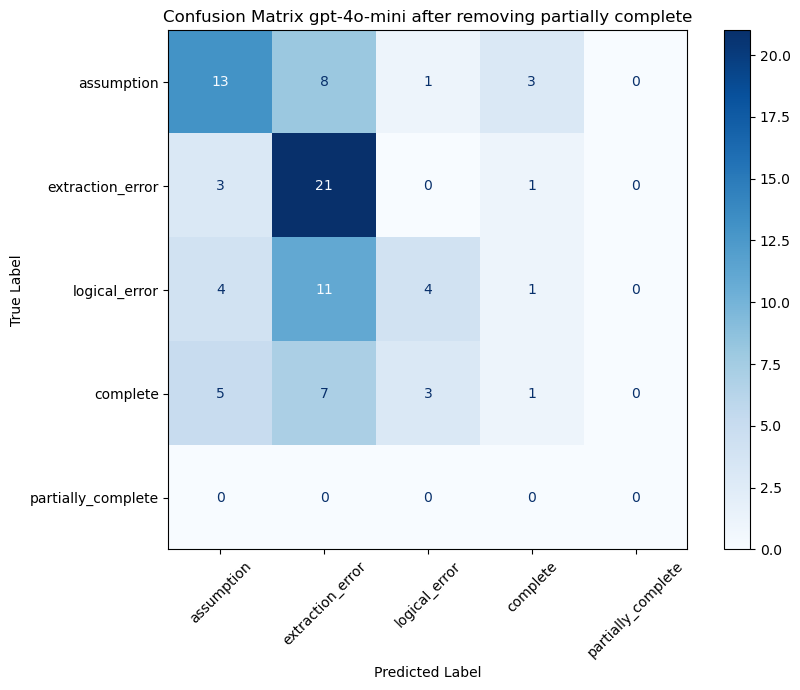

In [133]:
plot_confusion_matrix(
   df_compare_4cat_filtered,
    true_col="final_human_agreement",
    pred_col="gpt_4cat_prediction",
    labels=labels,
    title="Confusion Matrix gpt-4o-mini after removing partially complete"
)

## gpt-4o using K10

In [134]:
final_df_gpt_k10

,index,note,patient_id,criterion,rationale,medications,is_met,true_label,assessed_category,assessor_confidence,assessor_reason,assessor_evidence_ids,used_k,retrieved_count,latency_ms,error,llm_status,llm_error_type,llm_attempts
0,19,record date : 2107 - 10 - 24 toole county hosp...,115,DRUG-ABUSE,The clinical notes indicate that the patient i...,"['allopurinol 100 mg', 'amitriptyline 10 mg', ...",1,0,assumption,high,The model assumes that the use of Percocet and...,"[""115_3_0""]",10,7,2500,NaN,ok,NaN,1
1,23,record date : 2107 - 10 - 24 toole county hosp...,115,MAJOR-DIABETES,The patient has a history of diabetes mellitus...,"['diabeta', 'pravachol', 'atorvastatin', 'lopr...",0,1,partially_complete,medium,The model rationale correctly identifies that ...,"[""115_0_0"", ""115_1_0"", ""115_2_0"", ""115_3_0"", ""...",10,7,3045,NaN,ok,NaN,1
2,40,record date : 2088 - 05 - 21 patient name : cu...,119,ADVANCED-CAD,The patient is taking multiple medications for...,"['furosemide', 'asa (acetylsalicylic acid)', '...",1,0,logical_error,high,The model incorrectly concludes that the patie...,"[""119_1_0"", ""119_3_0""]",10,6,2189,NaN,ok,NaN,1
3,53,state. since this was her first episode of pro...,120,ADVANCED-CAD,The patient has a history of coronary artery d...,"['atenolol 100mg po qd', 'ecasa 325mg po qd', ...",1,0,extraction_error,high,The model's rationale incorrectly states that ...,"[""120_3_0""]",10,10,2568,NaN,ok,NaN,1
4,65,"nodules. no change. extremity 1 + edema left, ...",131,ABDOMINAL,The patient's clinical notes indicate a histor...,"['atenolol 25 mg bid', 'coumadin', 'ecotrin 32...",1,0,extraction_error,high,The model rationale incorrectly identifies umb...,"[""131_2_0""]",10,10,2341,NaN,ok,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,1085,record date : 2091 - 06 - 12 narrative history...,394,DRUG-ABUSE,"The patient has a history of alcohol abuse, wh...","['folic acid', 'ecotrin (aspirin enteric coate...",1,0,logical_error,high,The model rationale incorrectly equates alcoho...,"[""394_0_0"", ""394_2_1""]",10,9,4786,NaN,ok,NaN,1
104,1098,record date : 2077 - 11 - 10 reason for visit ...,396,DRUG-ABUSE,The patient has a history of marijuana use and...,"['aspirin 81 mg daily', 'calcium plus d 1 tabl...",1,0,complete,high,The model rationale correctly identifies the p...,"[""396_3_1""]",10,10,12057,NaN,ok,NaN,1
105,1105,record date : 2070 - 03 - 24 neurology clinic ...,399,ABDOMINAL,The patient has a history of abdominal surgery...,"['avandia 4 mg po q4', 'pravachol 20 qhs', 'fe...",1,0,logical_error,high,The model rationale incorrectly identifies the...,"[""399_1_0""]",10,10,13474,NaN,ok,NaN,1
106,1108,record date : 2069 - 10 - 20 ed neurology cons...,399,ASP-FOR-MI,The patient has a history of stroke and is rec...,"['avandia', 'pravachol', 'fentanyl patch', 'di...",0,1,extraction_error,high,The model rationale incorrectly states that th...,"[""399_1_0"", ""399_3_1""]",10,10,11359,NaN,ok,NaN,1


In [135]:
df_compare_k10 = pd.merge(
    combined_df,
   final_df_gpt_k10[["patient_id", "criterion", "assessed_category"]],
    on=["patient_id", "criterion"],
    how="left"
)

df_compare_k10 = df_compare_k10.rename(columns={
    "assessed_category": "gpt_k10_prediction"
})

In [136]:
report =classification_report(
 df_compare_k10['final_human_agreement'],
df_compare_k10['gpt_k10_prediction'],
    zero_division=0,
    output_dict=True
)

In [137]:
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_report_gpt_k10.csv", index=True)

# Display in notebook
display(report_df.round(3))

,precision,recall,f1-score,support
assumption,0.667,0.480,0.558,25.000
complete,0.529,0.562,0.545,16.000
extraction_error,0.857,0.720,0.783,25.000
logical_error,0.750,0.900,0.818,20.000
partially_complete,0.125,0.500,0.200,2.000
accuracy,0.659,0.659,0.659,0.659
macro avg,0.586,0.633,0.581,88.000
weighted avg,0.702,0.659,0.671,88.000


In [138]:
get_f1_score( df_compare_k10,"final_human_agreement","gpt_k10_prediction")

Micro F1: 0.659
Weighted F1: 0.671
